# SonicMap Research Report

Genre and continuous valence–arousal modeling, audio-native similarity search, cross-dataset validation, and playlist generation on real audio.

This notebook is an executed view of the canonical CSV/JSON experiment artifacts from Steps 4–11. It does not retrain models, so it remains quick to reproduce on CPU. All values below are loaded from disk rather than manually transcribed.


## Experimental scope

- **Genre:** GTZAN, 999 successfully processed tracks across 10 genres, with known duplicate and labeling limitations.
- **Mood:** DEAM, 1,802 excerpts with real continuous valence and arousal annotations.
- **Out-of-distribution evaluation:** 2,999 FMA Small tracks from the only three exact taxonomy overlaps: Hip-Hop, Pop, and Rock. One corrupt FMA MP3 was skipped.
- **Uncertainty:** five-fold t confidence intervals for model experiments and query-level bootstrap intervals for retrieval and playlists.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)
print(f"Artifact root: {ROOT}")


Artifact root: /Users/hkbuttar/sonicmap


## 1. Genre classification and augmentation

The CNN and gradient-boosted model were evaluated with stratified five-fold cross-validation. Augmented variants were confined to the training side of each fold to prevent near-duplicate leakage.


  model  augmented      mean    ci_low   ci_high
0   cnn      False  0.673693  0.591900  0.755487
2   cnn       True  0.758719  0.727793  0.789644
4   gbm      False  0.717704  0.693102  0.742305
6   gbm       True  0.731704  0.693373  0.770034

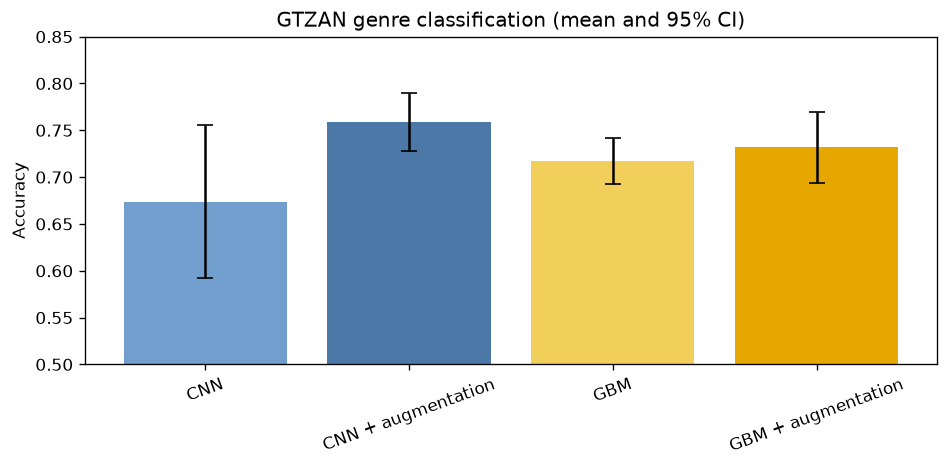

In [2]:
genre = pd.read_csv(ROOT / "classification/results/step4_classification_summary.csv")
accuracy = genre[genre.metric == "accuracy"].copy()
accuracy["condition"] = accuracy["model"].str.upper() + np.where(accuracy["augmented"], " + augmentation", "")

fig, ax = plt.subplots(figsize=(8, 4))
yerr = np.vstack([accuracy["mean"] - accuracy["ci_low"], accuracy["ci_high"] - accuracy["mean"]])
ax.bar(accuracy["condition"], accuracy["mean"], yerr=yerr, capsize=5, color=["#729ECE", "#4C78A8", "#F2CF5B", "#E6A700"])
ax.set(ylim=(0.5, 0.85), ylabel="Accuracy", title="GTZAN genre classification (mean and 95% CI)")
ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
accuracy[["model", "augmented", "mean", "ci_low", "ci_high"]]


The augmented CNN had the best observed accuracy (0.759). Its paired gain was 0.085, although the five-fold 95% interval narrowly included zero; this is promising rather than conclusive. The GBM augmentation effect was much smaller.


## 2. Continuous mood regression

Valence and arousal were modeled as continuous DEAM targets. R² is shown because it expresses improvement over a mean-target predictor; MAE and RMSE remain in the source artifact.


   model   target      mean    ci_low   ci_high
2    cnn  valence  0.381833  0.245720  0.517946
5    cnn  arousal  0.404263  0.214054  0.594472
8    gbm  valence  0.395050  0.347307  0.442792
11   gbm  arousal  0.446058  0.394596  0.497520

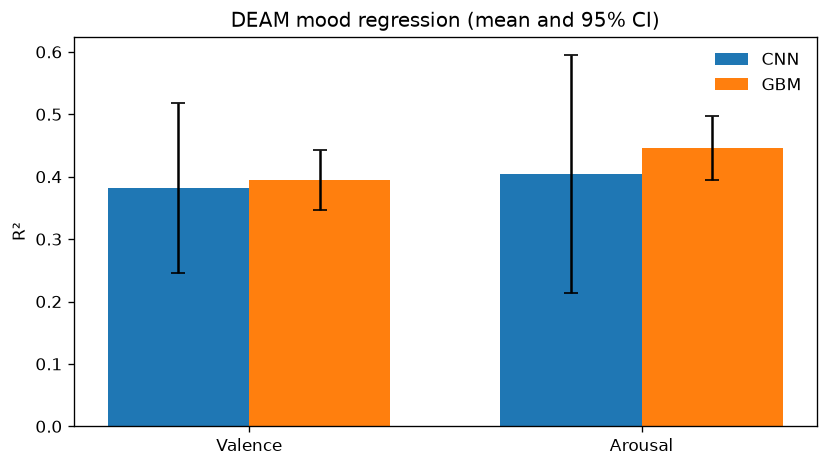

In [3]:
mood = pd.read_csv(ROOT / "mood/results/step5_mood_regression_summary.csv")
r2 = mood[mood.metric.str.endswith("_r2")].copy()
r2["target"] = r2.metric.str.replace("_r2", "", regex=False)

fig, ax = plt.subplots(figsize=(7, 4))
for offset, (model, group) in zip((-0.18, 0.18), r2.groupby("model")):
    x = np.arange(len(group)) + offset
    ax.bar(x, group["mean"], width=.36, label=model.upper())
    ax.errorbar(x, group["mean"], yerr=[group["mean"]-group["ci_low"], group["ci_high"]-group["mean"]], fmt="none", color="black", capsize=4)
ax.set_xticks(range(2), ["Valence", "Arousal"])
ax.set(ylabel="R²", title="DEAM mood regression (mean and 95% CI)")
ax.legend(frameon=False)
fig.tight_layout()
r2[["model", "target", "mean", "ci_low", "ci_high"]]


Mood was harder and noisier than genre classification, as expected for subjective annotations. GBM narrowly led the CNN, reaching R² 0.395 for valence and 0.446 for arousal.


## 3. Learned embedding spaces

The classification embedding reuses the genre CNN's 128-dimensional penultimate layer. The triplet network was trained separately with explicit same-genre positives and cross-genre negatives.


        embedding  embedding_silhouette_cosine  projection_silhouette_euclidean
0  classification                     0.333705                         0.512181
1         triplet                     0.254576                         0.207319

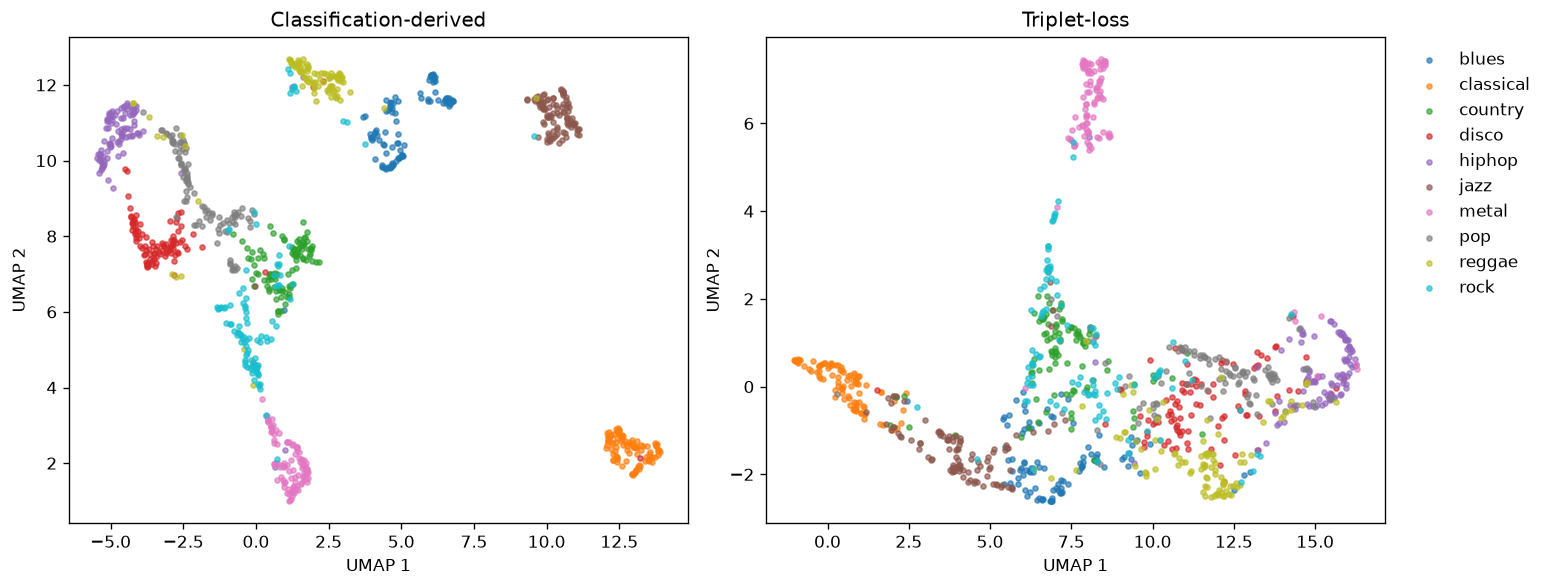

In [4]:
projection_files = {
    "Classification-derived": ROOT / "embeddings/results/classification/classification_projection.csv",
    "Triplet-loss": ROOT / "embeddings/results/triplet/triplet_projection.csv",
}
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (title, path) in zip(axes, projection_files.items()):
    frame = pd.read_csv(path)
    for label, group in frame.groupby("label"):
        ax.scatter(group.x, group.y, s=9, alpha=.65, label=label)
    ax.set(title=title, xlabel="UMAP 1", ylabel="UMAP 2")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
fig.tight_layout()

embedding_metrics = pd.DataFrame([
    {"embedding": name, **json.loads((ROOT / path).read_text())}
    for name, path in {
        "classification": "embeddings/results/classification/classification_embedding_metrics.json",
        "triplet": "embeddings/results/triplet/triplet_embedding_metrics.json",
    }.items()
])
embedding_metrics[["embedding", "embedding_silhouette_cosine", "projection_silhouette_euclidean"]]


The purpose-built objective learned—the triplet loss fell from 0.112 to 0.059—but it did not surpass the simpler classification representation on genre silhouette or downstream in-distribution retrieval.


## 4. Four-way similarity search

Precision@k uses same-genre agreement as a weak automated relevance signal. The metadata method directly uses that label, making it an oracle-like ceiling rather than audio retrieval.


                      method  precision_at_k    ci_low   ci_high
2   classification_embedding        0.889890  0.876374  0.903003
6          triplet_embedding        0.676977  0.656156  0.696296
10       engineered_features        0.522523  0.502800  0.541144
14            metadata_genre        1.000000  1.000000  1.000000

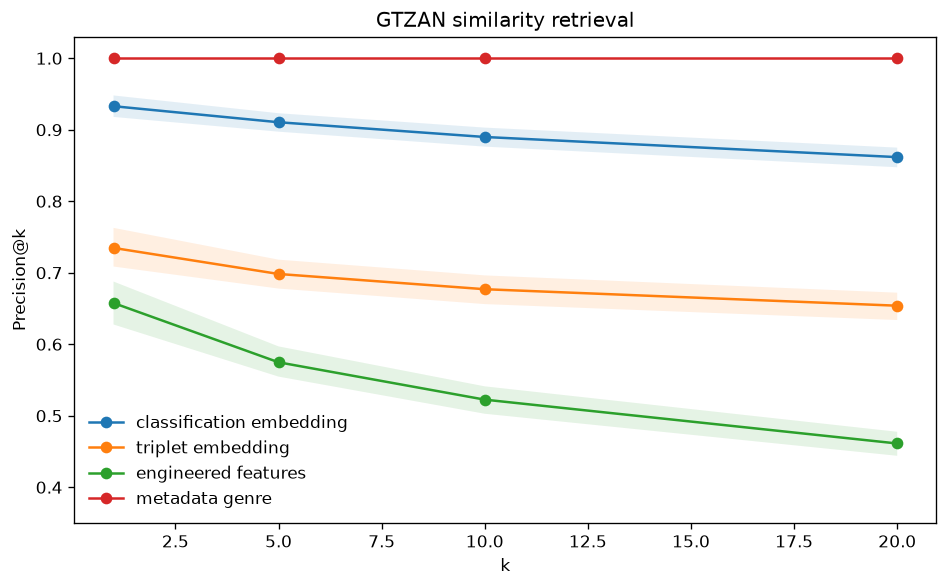

In [5]:
retrieval = pd.read_csv(ROOT / "similarity/results/step8_similarity_comparison.csv")
fig, ax = plt.subplots(figsize=(8, 5))
for method, group in retrieval.groupby("method", sort=False):
    ax.plot(group.k, group.precision_at_k, marker="o", label=method.replace("_", " "))
    ax.fill_between(group.k, group.ci_low, group.ci_high, alpha=.12)
ax.set(xlabel="k", ylabel="Precision@k", ylim=(0.35, 1.03), title="GTZAN similarity retrieval")
ax.legend(frameon=False)
fig.tight_layout()
retrieval[retrieval.k == 10][["method", "precision_at_k", "ci_low", "ci_high"]]


At k=10, the classification embedding scored 0.890, the triplet embedding 0.677, and engineered features 0.523. These are in-sample GTZAN results and should not be read as human perceptual-similarity scores.


## 5. Cross-dataset generalization

GTZAN-trained models were evaluated on FMA without retraining. Retrieval drops were chance-adjusted because FMA's exact-overlap evaluation has three classes while GTZAN has ten.


    genre     n  accuracy
0  hiphop  1000  0.458000
1     pop  1000  0.147000
2    rock   999  0.432432

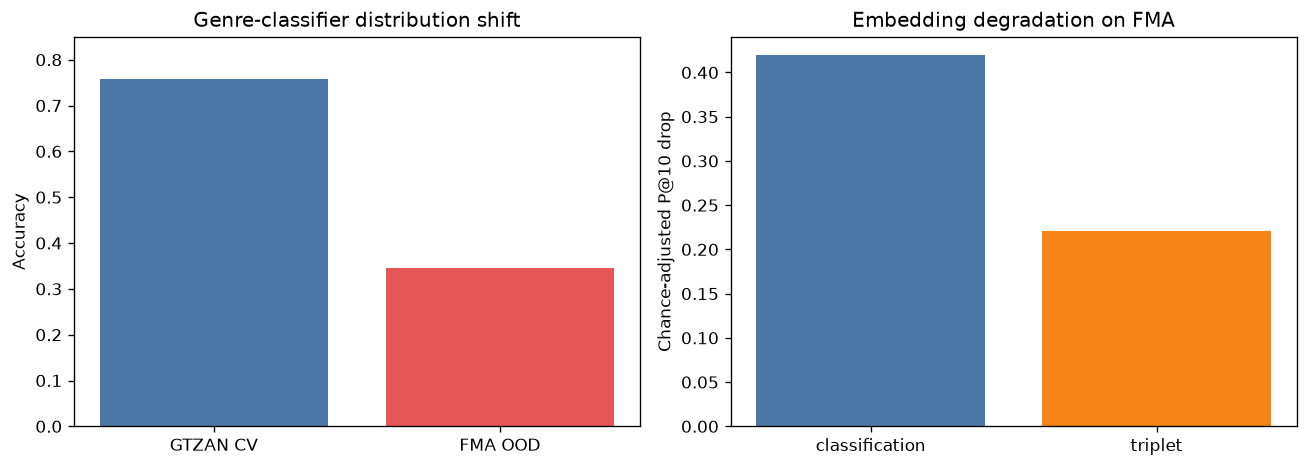

In [6]:
generalization = pd.read_csv(ROOT / "generalization/results/step9_classification_generalization.csv")
per_genre = pd.read_csv(ROOT / "generalization/results/step9_per_genre_accuracy.csv")
ood = pd.read_csv(ROOT / "generalization/results/step9_similarity_generalization.csv")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(["GTZAN CV", "FMA OOD"], [generalization.gtzan_cv_accuracy.iloc[0], generalization.accuracy.iloc[0]], color=["#4C78A8", "#E45756"])
axes[0].set(ylim=(0, 0.85), ylabel="Accuracy", title="Genre-classifier distribution shift")
k10 = ood[ood.k == 10]
axes[1].bar(k10.method.str.replace("_embedding", "", regex=False), k10.adjusted_precision_drop, color=["#4C78A8", "#F58518"])
axes[1].set(ylabel="Chance-adjusted P@10 drop", title="Embedding degradation on FMA")
fig.tight_layout()
per_genre[["genre", "n", "accuracy"]]


Classifier accuracy fell from 0.759 to 0.346, with especially weak FMA Pop accuracy (0.147). The classification embedding retained slightly higher absolute FMA P@10, but the triplet embedding had the smaller chance-adjusted degradation (0.221 versus 0.419), its clearest positive result.


## 6. Playlist generation

Playlists used a greedy local walk with a gradually increasing target distance from the seed. Each method was compared with random playlists inside its own space; raw cosine levels are not comparable across independently trained spaces.


                     method                    metric  playlist_mean  random_mean  mean_difference  difference_ci_low  \
0  classification_embedding       pairwise_similarity       0.808932     0.418607         0.390325           0.381244   
2  classification_embedding       seed_genre_fraction       0.756000     0.189480         0.566520           0.512736   
3  classification_embedding  monotonic_drift_fraction       0.932222     0.555467         0.376756           0.358883   
5         triplet_embedding       pairwise_similarity       0.936247     0.693422         0.242824           0.239045   
7         triplet_embedding       seed_genre_fraction       0.496000     0.190060         0.305940           0.250667   
8         triplet_embedding  monotonic_drift_fraction       0.948889     0.556400         0.392489           0.369441   

   difference_ci_high  
0            0.398931  
2            0.615947  
3            0.394558  
5            0.246417  
7            0.362263  
8       

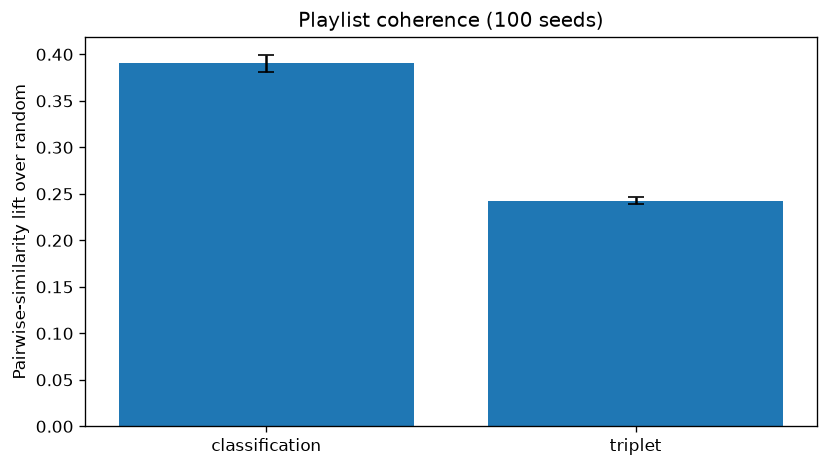

In [7]:
playlists = pd.read_csv(ROOT / "similarity/results/playlists/step10_playlist_coherence.csv")
pairwise = playlists[playlists.metric == "pairwise_similarity"].copy()
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(pairwise.method.str.replace("_embedding", "", regex=False), pairwise.mean_difference,
       yerr=[pairwise.mean_difference-pairwise.difference_ci_low, pairwise.difference_ci_high-pairwise.mean_difference], capsize=5)
ax.set(ylabel="Pairwise-similarity lift over random", title="Playlist coherence (100 seeds)")
fig.tight_layout()
playlists[playlists.metric.isin(["pairwise_similarity", "seed_genre_fraction", "monotonic_drift_fraction"])][
    ["method", "metric", "playlist_mean", "random_mean", "mean_difference", "difference_ci_low", "difference_ci_high"]
]


Both methods produced coherent, progressively drifting playlists. The classification representation had the larger pairwise-similarity lift over random (0.390 versus 0.243) and greater seed-genre retention.


## 7. Consolidated findings and limitations


In [8]:
comparison = pd.read_csv(ROOT / "results/step11_comparison.csv")
print((ROOT / "results/step11_findings.md").read_text())
comparison


# Step 11 — Results and Honest Comparison

## Headline results

| Question | Result |
|---|---|
| Did augmentation help? | CNN accuracy changed by +0.085 (95% CI -0.003 to +0.173); GBM changed by +0.014 (-0.017 to +0.045). |
| Best genre classifier | Augmented CNN: 0.759 accuracy versus augmented GBM: 0.732. |
| Mood regression | GBM reached R²=0.395 valence and R²=0.446 arousal; gains over CNN were small. |
| Best in-sample audio retrieval | Classification embedding P@10=0.890; triplet embedding P@10=0.677. |
| Cross-dataset classification | FMA accuracy=0.346, an absolute drop of 0.413 from GTZAN CV. |
| More robust embedding OOD | Chance-adjusted P@10 drop: classification=0.419, triplet=0.221. The triplet space degraded less but remained slightly weaker on FMA. |
| Playlist coherence lift over random | Classification=+0.390; triplet=+0.243. |

## Honest interpretation

Augmentation produced a substantial observed CNN gain at this dataset size, but the five-fold paired 95% interval n

                 section                comparison                                metric     value    ci_low  \
0           augmentation                       cnn                        accuracy_delta  0.085025 -0.003069   
1           augmentation                       gbm                        accuracy_delta  0.014000 -0.016855   
2   genre_classification                       cnn                              accuracy  0.758719  0.727793   
3   genre_classification                       gbm                              accuracy  0.731704  0.693373   
4        mood_regression                       cnn                            valence_r2  0.381833  0.245720   
5        mood_regression                       gbm                            valence_r2  0.395050  0.347307   
6        mood_regression             gbm_minus_cnn                      valence_r2_delta  0.013217 -0.152395   
7        mood_regression                       cnn                            arousal_r2  0.404263  0.21

## 8. Complete findings ledger

The tables below intentionally preserve every reported quantitative result, not only the headline metrics plotted above. They are printed without notebook display truncation and retain confidence intervals, sample counts, and methodological qualifiers from the canonical artifacts.


### 8.1 Genre classification: every model, condition, and metric


In [9]:
genre_all = pd.read_csv(ROOT / "classification/results/step4_classification_summary.csv")
print(genre_all.to_string(index=False))


model  augmented   metric     mean   ci_low  ci_high  n_folds
  cnn      False accuracy 0.673693 0.591900 0.755487        5
  cnn      False f1_macro 0.659527 0.574257 0.744797        5
  cnn       True accuracy 0.758719 0.727793 0.789644        5
  cnn       True f1_macro 0.753030 0.725867 0.780193        5
  gbm      False accuracy 0.717704 0.693102 0.742305        5
  gbm      False f1_macro 0.716803 0.689720 0.743886        5
  gbm       True accuracy 0.731704 0.693373 0.770034        5
  gbm       True f1_macro 0.726743 0.686642 0.766845        5


### 8.2 Mood regression: MAE, RMSE, and R² for both targets and models


In [10]:
mood_all = pd.read_csv(ROOT / "mood/results/step5_mood_regression_summary.csv")
print(mood_all.to_string(index=False))


model       metric     mean   ci_low  ci_high  n_folds
  cnn  valence_mae 0.730647 0.625619 0.835675        5
  cnn valence_rmse 0.919542 0.805714 1.033370        5
  cnn   valence_r2 0.381833 0.245720 0.517946        5
  cnn  arousal_mae 0.774882 0.654843 0.894920        5
  cnn arousal_rmse 0.982003 0.839429 1.124576        5
  cnn   arousal_r2 0.404263 0.214054 0.594472        5
  gbm  valence_mae 0.728811 0.705991 0.751631        5
  gbm valence_rmse 0.910851 0.893427 0.928274        5
  gbm   valence_r2 0.395050 0.347307 0.442792        5
  gbm  arousal_mae 0.760281 0.718595 0.801967        5
  gbm arousal_rmse 0.952296 0.906864 0.997729        5
  gbm   arousal_r2 0.446058 0.394596 0.497520        5


### 8.3 Triplet optimization diagnostics

Loss was not strictly monotonic at every epoch, but the overall decline demonstrates that the training objective was optimized. That alone did not guarantee better downstream retrieval.


 epoch  triplet_loss
     1      0.111925
     2      0.099728
     3      0.091916
     4      0.083091
     5      0.082710
     6      0.084562
     7      0.080228
     8      0.079300
     9      0.071497
    10      0.077536
    11      0.070808
    12      0.067256
    13      0.064447
    14      0.063833
    15      0.058835


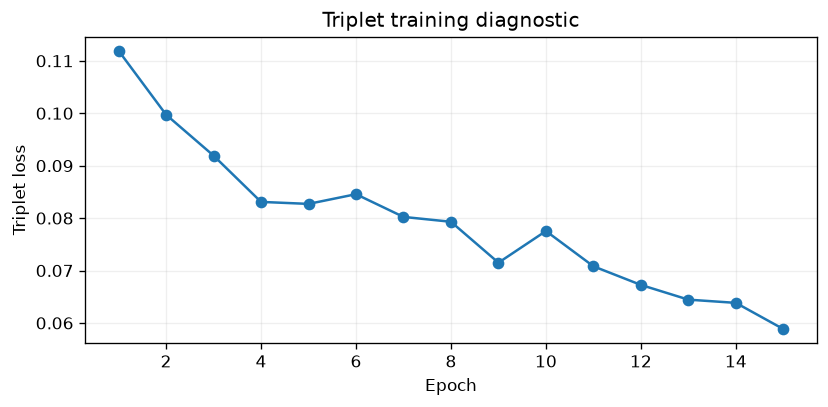

In [11]:
triplet_history = pd.read_csv(ROOT / "embeddings/results/triplet/triplet_training_history.csv")
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(triplet_history.epoch, triplet_history.triplet_loss, marker="o")
ax.set(xlabel="Epoch", ylabel="Triplet loss", title="Triplet training diagnostic")
ax.grid(alpha=.2)
fig.tight_layout()
print(triplet_history.to_string(index=False))


### 8.4 Similarity search: cosine and Euclidean results

Cosine and Euclidean rankings were effectively identical for the L2-normalized learned embeddings. Engineered features performed slightly better with cosine. The full distance table follows.


In [12]:
distance_all = pd.read_csv(ROOT / "similarity/results/step8_distance_comparison.csv")
print(distance_all.to_string(index=False))


                  method   distance_metric  k  precision_at_k   ci_low  ci_high  n_queries  n_bootstrap
classification_embedding            cosine  1        0.932933 0.917918 0.947973        999         2000
classification_embedding            cosine  5        0.910511 0.897297 0.923123        999         2000
classification_embedding            cosine 10        0.889890 0.876374 0.903003        999         2000
classification_embedding            cosine 20        0.861712 0.847548 0.875026        999         2000
classification_embedding         euclidean  1        0.932933 0.917918 0.947948        999         2000
classification_embedding         euclidean  5        0.910511 0.896697 0.922923        999         2000
classification_embedding         euclidean 10        0.889890 0.876677 0.903303        999         2000
classification_embedding         euclidean 20        0.861712 0.846395 0.875528        999         2000
       triplet_embedding            cosine  1        0.734735 0.

### 8.5 FMA generalization: classifier, per-genre, and retrieval results

The classifier suffered a large absolute distribution-shift loss. Pop was the weakest aligned FMA genre. The classification embedding remained slightly stronger in absolute FMA precision, while the triplet embedding showed the smaller chance-adjusted drop at every reported k.


In [13]:
print("CLASSIFICATION")
print(pd.read_csv(ROOT / "generalization/results/step9_classification_generalization.csv").to_string(index=False))
print("\nPER GENRE")
print(pd.read_csv(ROOT / "generalization/results/step9_per_genre_accuracy.csv").to_string(index=False))
print("\nSIMILARITY")
print(pd.read_csv(ROOT / "generalization/results/step9_similarity_generalization.csv").to_string(index=False))


CLASSIFICATION
          dataset  n_tracks  n_genres  accuracy  accuracy_ci_low  accuracy_ci_high  f1_macro  gtzan_cv_accuracy  absolute_accuracy_drop
fma_exact_overlap      2999         3  0.345782         0.329777          0.361787  0.128196           0.758719                0.412937

PER GENRE
 label    n  accuracy  genre
     4 1000  0.458000 hiphop
     7 1000  0.147000    pop
     9  999  0.432432   rock

SIMILARITY
                  method  k  fma_precision_at_k  fma_ci_low  fma_ci_high  gtzan_precision_at_k  raw_precision_drop  fma_random_baseline  gtzan_random_baseline  fma_adjusted_precision  gtzan_adjusted_precision  adjusted_precision_drop
classification_embedding  1            0.658219    0.640880     0.674892              0.932933            0.274714             0.333333                    0.1                0.487329                  0.925481                 0.438152
classification_embedding  5            0.643348    0.632409     0.654625              0.910511            

### 8.6 Playlist evaluation: every coherence and drift metric

Both learned spaces beat their own random baselines for pairwise similarity, adjacent similarity, seed-genre retention, and monotonic drift. Generated playlists ended closer to their seeds than random playlists, which is expected from a coherence-controlled traversal. Cross-space conclusions use lift over random, not raw cosine values.


In [14]:
playlist_all = pd.read_csv(ROOT / "similarity/results/playlists/step10_playlist_coherence.csv")
print(playlist_all.to_string(index=False))


                  method                   metric  playlist_mean  random_mean  mean_difference  difference_ci_low  difference_ci_high  n_seed_tracks  random_playlists_per_seed
classification_embedding      pairwise_similarity       0.808932     0.418607         0.390325           0.381244            0.398931            100                         50
classification_embedding      adjacent_similarity       0.928777     0.417725         0.511051           0.506556            0.515345            100                         50
classification_embedding      seed_genre_fraction       0.756000     0.189480         0.566520           0.512736            0.615947            100                         50
classification_embedding monotonic_drift_fraction       0.932222     0.555467         0.376756           0.358883            0.394558            100                         50
classification_embedding      final_seed_distance       0.434643     0.582004        -0.147360          -0.159735       

### 8.7 Findings not yet resolved automatically

- Genre precision is only a weak proxy for perceptual similarity.
- The metadata baseline is an oracle-like ceiling, not an audio system.
- The generated Step 8 and Step 10 qualitative-review CSVs remain intentionally unrated; no human-listening conclusion is fabricated here.
- Step 8 is in-sample retrieval. Step 9 is the genuine unseen-distribution test.
- FMA used 2,999 of 3,000 selected tracks because one source MP3 was corrupt.
- The triplet embedding's lower cross-dataset degradation is a robustness result, not evidence that it was the best absolute retriever.


## 9. Testing and validation audit

Step 12 combined the 39-test unit/integration suite with an artifact-backed audit. It checked random baselines, fold integrity, augmentation leakage, triplet optimization and initial-to-final silhouette, FMA alignment, retrieval sanity, and playlist lift.


In [15]:
validation_checks = pd.read_csv(ROOT / "validation/results/step12_validation_checks.csv")
print((ROOT / "validation/results/step12_validation_report.md").read_text())
validation_checks


# Step 12 — Testing and Validation

- Passed: 18
- Inconclusive: 1
- Failed: 0

| Check | Status | Observed | Threshold | Severity |
|---|---:|---:|---:|---|
| genre_cnn_original_beats_random | pass | 0.673693 [0.591900, 0.755487] | CI versus 0.1 | critical |
| genre_cnn_augmented_beats_random | pass | 0.758719 [0.727793, 0.789644] | CI versus 0.1 | critical |
| genre_gbm_original_beats_random | pass | 0.717704 [0.693102, 0.742305] | CI versus 0.1 | critical |
| genre_gbm_augmented_beats_random | pass | 0.731704 [0.693373, 0.770034] | CI versus 0.1 | critical |
| mood_cnn_valence_r2_beats_mean_predictor | pass | 0.381833 [0.245720, 0.517946] | CI versus 0.0 | critical |
| mood_cnn_arousal_r2_beats_mean_predictor | pass | 0.404263 [0.214054, 0.594472] | CI versus 0.0 | critical |
| mood_gbm_valence_r2_beats_mean_predictor | pass | 0.395050 [0.347307, 0.442792] | CI versus 0.0 | critical |
| mood_gbm_arousal_r2_beats_mean_predictor | pass | 0.446058 [0.394596, 0.497520] | CI versus 0.0 |

                                                 name        status                                       observed  \
0                     genre_cnn_original_beats_random          pass                  0.673693 [0.591900, 0.755487]   
1                    genre_cnn_augmented_beats_random          pass                  0.758719 [0.727793, 0.789644]   
2                     genre_gbm_original_beats_random          pass                  0.717704 [0.693102, 0.742305]   
3                    genre_gbm_augmented_beats_random          pass                  0.731704 [0.693373, 0.770034]   
4            mood_cnn_valence_r2_beats_mean_predictor          pass                  0.381833 [0.245720, 0.517946]   
5            mood_cnn_arousal_r2_beats_mean_predictor          pass                  0.404263 [0.214054, 0.594472]   
6            mood_gbm_valence_r2_beats_mean_predictor          pass                  0.395050 [0.347307, 0.442792]   
7            mood_gbm_arousal_r2_beats_mean_predictor   

All 18 critical and positive sanity checks passed. The FMA classifier comparison with a balanced three-class random baseline remained **inconclusive**, because its 95% confidence interval crossed chance. Human perceptual similarity remains unvalidated until the qualitative listening sheets are completed.


### Reproducibility

Regenerate this executed notebook from the repository root with:

```bash
.venv/bin/python notebooks/build_research_notebook.py
```

Model training is intentionally separate. The notebook consumes saved experiment artifacts, making reporting deterministic and inexpensive while keeping the original training commands auditable in the README.
